**EDA Fase 1: Diagnóstico de RECH6 (Antropometría) - Serie Histórica (2007-2024)**

Objetivo: Cargar los datos crudos, extraer las etiquetas de variables y separar las operativas de las analíticas. Se inicia en 2007 porque es el año en que ENDES comenzó a registrar el estándar moderno de la OMS (`HC70`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mnp.ingestion.loader import load_endes

# 1. Carga de historial con metadatos desde 2007 hasta 2024
history = load_endes(year=range(2007, 2025), module='anthropometry', record='rech6', meta=True)

# 2. Consolidación de datos y etiquetas
frames = []
diccionario = {}

# IMPORTANTE: Iteramos en orden ascendente (del año más antiguo al más reciente)
# load_endes internamente trae los años en reversa (2024, 2023...), por lo que si no 
# ordenamos al revés, las etiquetas viejas pisarían a las nuevas.
for yr in sorted(history.keys()):
    df_yr, meta_yr = history[yr]
    frames.append(df_yr.assign(year=yr))
    diccionario.update(meta_yr.column_names_to_labels)

df_raw = pd.concat(frames, ignore_index=True)

print(f"Registros totales (2007-2024): {len(df_raw)}")
print(f"Columnas totales: {df_raw.shape[1]}")

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k
2026-05-28 02:29:52.203 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /workspace


2026-05-28 02:29:52.665 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-05-28 02:29:52.928 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-05-28 02:29:53.315 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-05-28 02:29:53.541 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-05-28 02:29:53.759 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.sav desde Modulo74 [Alias: rech6]
2026-05-28 02:29:54.017 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.sav desde Modulo74 [Alias: rech6]
2026-05-28 02:29:54.356 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-05-28 02:29:54.580 | INFO     | mnp.ingesti

In [2]:
# 3. Identificación de variables por porcentaje de nulos
nulos = df_raw.isna().mean().sort_values(ascending=False) * 100

print("Variables con > 90% de nulos:")
for col, pct in nulos[nulos > 90].items():
    etiqueta = diccionario.get(col, 'Sin etiqueta')
    print(f"{col:5s} | {pct:5.1f}% | {etiqueta}")

print("\n---\nResto de variables:")
for col, pct in nulos[nulos <= 90].items():
    etiqueta = diccionario.get(col, 'Sin etiqueta')
    print(f"{col:5s} | {pct:5.1f}% | {etiqueta}")

Variables con > 90% de nulos:
HC58  | 100.0% | Está de acuerdo con enviar los datos a un especialista
f     |  96.7% | None
HV005A |  95.4% | Factor mediciones niño
HC57A |  93.8% | Nivel de anemia NUEVA DIRECTRIZ OMS 2024/RM 251-2024-MINSA
HC56A |  93.8% | Nivel de hemoglobina ajustado por altitud (g/dl-1 decimal) NUEVA DIRECTRIZ OMS 2024/RM 251-2024-MINSA

---
Resto de variables:
ID1   |  58.3% | Año
HC17  |  49.9% | Date measured (day)
HC18  |  49.9% | Date measured (month)
HC63  |  37.1% | Intervalo de los nacimientos anteriores al niño
HC53  |  12.1% | Nivel de hemoglobina (g/dl-1 decimal)
HC56  |  12.1% | Nivel de hemoglobina ajustado por altitud (g/dl-1 decimal) RM 363-2022-MINSA
HC57  |  12.0% | Nivel de anemia RM 363-2022-MINSA
HC55  |   8.0% | Resultado de medir (hemoglobina)
HC52  |   7.7% | Leyó la declaración de consentimiento
HC51  |   7.7% | Número de orden del padre o responsable
HC64  |   6.8% | Número de orden de nacimiento
HC62  |   5.0% | El año más alto de educació

**Decisiones de Pre-Filtro (Ruido y Redundancia)**

Tras revisar la lista anterior, descartamos:
- Administrativas / Entrevista: `HC58`, `HC51`, `HC52`, `HC55`, `HC13`, `HC15`
- Fechas y tiempos (ya tenemos `HC1` edad): `HC16`, `HC17`, `HC18`, `HC19`, `HC30`, `HC31`, `HC32`, `HC33`
- Indicadores de crecimiento antiguos (percentiles y z-scores CDC/NCHS): `HC4` a `HC12`
- Orden y expansión (por ahora no se usan en este nivel): `HC60`, `HV005A`
- Variables vacías históricas o irrelevantes: `RECH6`, `f`
*(Nota: Mantenemos `ID1` para tener trazabilidad del año de la encuesta en caso de recolección continua)*

In [3]:
# 4. Separar variables analíticas y validar missings reales
vars_descartar = [
    'HC58', 'HC51', 'HC52', 'HC55', 'HC13', 'HC15',
    'HC16', 'HC17', 'HC18', 'HC19', 'HC30', 'HC31', 'HC32', 'HC33',
    'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12',
    'HC60', 'HV005A', 'RECH6', 'f'
]

# Guardamos solo las analíticas para la exploración univariada
vars_analiticas = [col for col in df_raw.columns if col not in vars_descartar]
df_analitico = df_raw[vars_analiticas].copy()

print(f"Columnas tras pre-filtro: {df_analitico.shape[1]}")
print("Variables analíticas a explorar:", vars_analiticas)

Columnas tras pre-filtro: 22
Variables analíticas a explorar: ['HHID', 'HC0', 'HC1', 'HC2', 'HC3', 'HC27', 'HC53', 'HC56', 'HC57', 'HC61', 'HC62', 'HC63', 'HC64', 'HC68', 'HC70', 'HC71', 'HC72', 'HC73', 'year', 'ID1', 'HC56A', 'HC57A']


**Nota Analítica: Entendiendo los Z-Scores de la OMS (`HC70`, `HC71`, `HC72`, `HC73`)**

En el submódulo de antropometría (`RECH6`), la ENDES entrega los indicadores nutricionales como "Z-scores" (Desviaciones Estándar respecto a una población sana de referencia dictada por la OMS). Los 4 principales son vitales para nuestro estudio:

1. **`HC70` (Talla/Edad):** Mide la **Desnutrición Crónica** (Retardo en el crecimiento). *Esta es nuestra variable objetivo principal o "Target".*
2. **`HC71` (Peso/Edad):** Mide la **Desnutrición Global** (Insuficiencia ponderal).
3. **`HC72` (Peso/Talla):** Mide la **Desnutrición Aguda** (Emaciación o delgadez extrema a corto plazo).
4. **`HC73` (IMC/Edad):** Índice de Masa Corporal para la edad. Muy útil para detectar **Sobrepeso y Obesidad infantil** (si el valor es alto) o delgadez severa.

Mantener el `HC73` (junto con el resto) en nuestro dataset limpio nos permite hacer análisis cruzados, como investigar la "Doble Carga de Malnutrición" (presencia de desnutrición crónica y sobrepeso en la misma población infantil).

**Detección de Códigos Especiales y Distribución (Previo a Limpieza)**

Verificamos si los z-scores (`HC70`, `HC71`, `HC72`, `HC73`) contienen códigos ENDES de "no aplicable" (9996-9999) e imprimimos estadísticas textuales para registro algorítmico.

HC70 (Talla/Edad de la Desviación Estándar de la mediana de referencia (según la OMS)): 0.4% de códigos inválidos
HC71 (Peso/Edad de la Desviación Estándar de la mediana de referencia (según la OMS)): 0.4% de códigos inválidos
HC72 (Peso/Talla Desviación Estándar de la mediana de referencia (según la OMS)): 0.4% de códigos inválidos
HC73 (Desviación Estándar del IMC (según la OMS)): 0.4% de códigos inválidos

--- Estadísticas Descriptivas ---
count    285284.00
mean         -0.95
std           1.08
min          -6.00
25%          -1.66
50%          -0.94
75%          -0.23
max           5.97
Name: HC70, dtype: float64

Valores extremos biológicos (Z < -6 o Z > 6): 0 registros


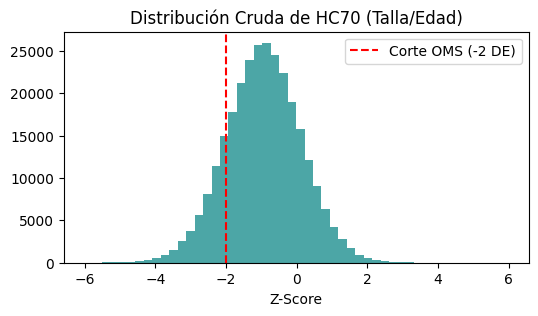


Media del Z-score (HC70) por año:
year
2007   -1.44
2008   -1.36
2009   -1.30
2010   -1.28
2011   -1.23
2012   -1.15
2013   -1.14
2014   -1.02
2015   -0.94
2016   -0.93
2017   -0.87
2018   -0.87
2019   -0.84
2020   -0.77
2021   -0.74
2022   -0.81
2023   -0.85
2024   -0.86
Name: HC70, dtype: float64


In [4]:
# 5. Detección de códigos y estadísticas descriptivas numéricas
ZSCORE_COLS = ['HC70', 'HC71', 'HC72', 'HC73']
INVALID = {9996, 9997, 9998, 9999}

for col in ZSCORE_COLS:
    s = pd.to_numeric(df_analitico[col], errors='coerce')
    pct_invalido = s.isin(INVALID).mean() * 100
    print(f"{col} ({diccionario.get(col, '')}): {pct_invalido:.1f}% de códigos inválidos")

s_hc70 = pd.to_numeric(df_analitico['HC70'], errors='coerce')
s_valid = s_hc70[~s_hc70.isin(INVALID)].dropna()
s_scaled = s_valid / 100  # Escalar a desviaciones estándar reales

print("\n--- Estadísticas Descriptivas ---")
print(s_scaled.describe().round(2))
outliers_extremos = (s_scaled.abs() > 6).sum()
print(f"\nValores extremos biológicos (Z < -6 o Z > 6): {outliers_extremos} registros")

plt.figure(figsize=(6,3))
plt.hist(s_scaled, bins=50, color='teal', alpha=0.7)
plt.axvline(-2, color='red', linestyle='--', label='Corte OMS (-2 DE)')
plt.title('Distribución Cruda de HC70 (Talla/Edad)')
plt.xlabel('Z-Score')
plt.legend()
plt.show()

print("\nMedia del Z-score (HC70) por año:")
print((df_analitico[~df_analitico['HC70'].isin(INVALID)].assign(HC70=lambda x: x['HC70']/100)
       .groupby('year')['HC70'].mean().round(2)))